In [1]:
from pathlib import Path
from functools import lru_cache
import re
import json
@lru_cache(maxsize=1)
def find_root():
    p = Path.cwd()
    for parent in [p] + list(p.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Root not found")



PROJ_ROOT = find_root()
DATA_DIR = PROJ_ROOT / "data"
RESULT_DIR = PROJ_ROOT / "results" / "qo"
RESULT_DIR.mkdir(exist_ok=True, parents=True)



def load_data(data_name):
    data_name = f"{data_name}"+"_500.json"
    with open(DATA_DIR / data_name, "r") as f:
        data = json.load(f)
    return data
dataset = ['hpqa','2wiki','msqa']



In [2]:
from transformers import (
    AutoTokenizer,
)

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B", padding_side="left", use_fast=True)


/data/qiuyk/workshop/exp/ReAct/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from datasets import Dataset as HFDataset
import numpy as np

def compute_context_len(data):
    if isinstance(data, list):
        hf_dataset = HFDataset.from_list(data)
    else:
        hf_dataset = data

    def compute_len(batch):
        enc = tokenizer(
            batch["context"],
            add_special_tokens=False,
            truncation=False,
            return_attention_mask=False,
            return_token_type_ids=False,
        )
        return {"context_len": [len(ids) for ids in enc["input_ids"]]}

    hf_dataset = hf_dataset.map(
        compute_len,
        batched=True,
        batch_size=2048,
        num_proc=4,   # 可以先小一点
    )

    return np.array(hf_dataset["context_len"], dtype=np.int32)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_len_hist(
    lengths,
    bins=50,
    xlim=None,
    ylim=None,
    bin_range=None,
    density=False,
    logy=False,
    title="Length histogram",
    xlabel="Length",
    ylabel=None,
):
    lengths = np.asarray(lengths)
    lengths = lengths[np.isfinite(lengths)]

    # --- Compute statistics ---
    mean_val = np.mean(lengths)
    median_val = np.median(lengths)
    min_val = np.min(lengths)
    max_val = np.max(lengths)

    fig, ax = plt.subplots(figsize=(9, 5))

    hist_kwargs = dict(bins=bins, density=density)
    if bin_range is not None and isinstance(bins, (int, np.integer)):
        hist_kwargs["range"] = bin_range

    ax.hist(lengths, **hist_kwargs, alpha=0.7, edgecolor="black")

    # --- Plot statistical markers ---
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_val:.2f}")
    ax.axvline(median_val, color="green", linestyle="-.", linewidth=2, label=f"Median = {median_val:.2f}")
    ax.axvline(min_val, color="blue", linestyle=":", linewidth=2, label=f"Min = {min_val:.2f}")
    ax.axvline(max_val, color="purple", linestyle=":", linewidth=2, label=f"Max = {max_val:.2f}")

    # --- Annotation box ---
    stats_text = (
        f"Mean: {mean_val:.2f}\n"
        f"Median: {median_val:.2f}\n"
        f"Min: {min_val:.2f}\n"
        f"Max: {max_val:.2f}"
    )
    ax.text(
        0.98, 0.98, stats_text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

    # --- Labels and formatting ---
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel or ("Density" if density else "Count"))

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if logy:
        ax.set_yscale("log")

    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Total samples: {len(lengths)}")

In [5]:
context_len = {}
for benchmark in dataset:
    data = load_data(benchmark)
    context_len[benchmark] = compute_context_len(data)

Map (num_proc=4): 100%|██████████| 500/500 [00:01<00:00, 351.43 examples/s]


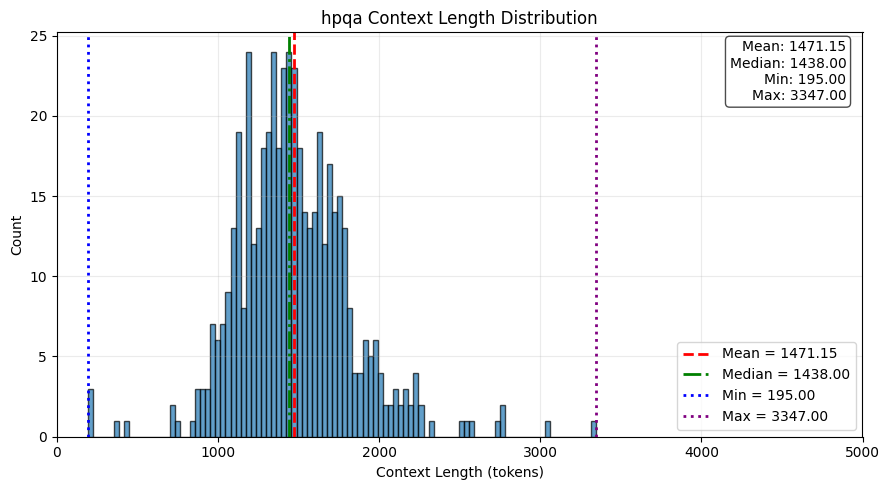

Total samples: 500


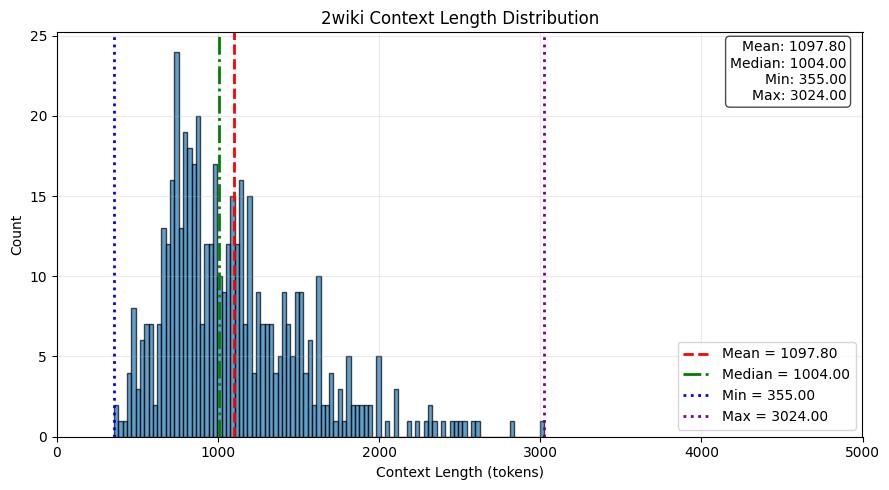

Total samples: 500


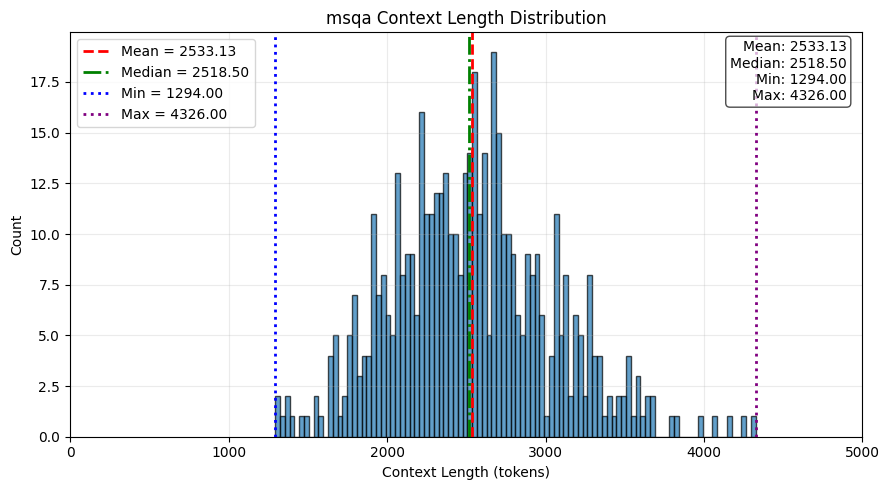

Total samples: 500


In [7]:
for benchmark in context_len:
    plot_len_hist(
        context_len[benchmark],
        bins=100,
        xlim=(0, 5000),
        title=f"{benchmark} Context Length Distribution",
        xlabel="Context Length (tokens)",
    )

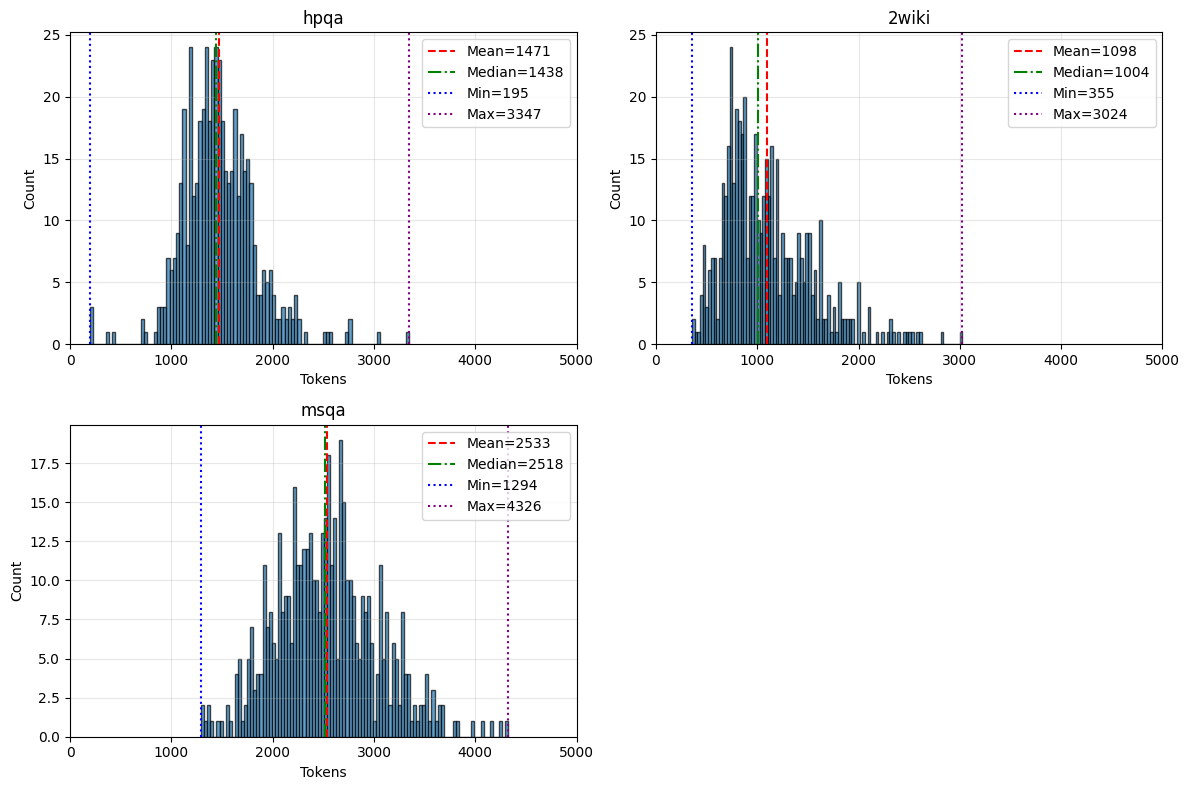

In [11]:
import matplotlib.pyplot as plt
import math
import numpy as np

benchmarks = list(context_len.keys())
n = len(benchmarks)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for i, benchmark in enumerate(benchmarks):
    ax = axes[i]
    lengths = np.asarray(context_len[benchmark])

    ax.hist(lengths, bins=100, alpha=0.7, edgecolor="black")

    # --- 统计值 ---
    mean_val = lengths.mean()
    median_val = np.median(lengths)
    min_val = lengths.min()
    max_val = lengths.max()

    # --- 画线 ---
    ax.axvline(mean_val, color="red", linestyle="--", label=f"Mean={mean_val:.0f}")
    ax.axvline(median_val, color="green", linestyle="-.", label=f"Median={median_val:.0f}")
    ax.axvline(min_val, color="blue", linestyle=":", label=f"Min={min_val:.0f}")
    ax.axvline(max_val, color="purple", linestyle=":", label=f"Max={max_val:.0f}")

    # # --- 右上角统计框 ---
    # stats_text = (
    #     f"Mean: {mean_val:.0f}\n"
    #     f"Median: {median_val:.0f}\n"
    #     f"Min: {min_val:.0f}\n"
    #     f"Max: {max_val:.0f}"
    # )
    # ax.text(
    #     0.98, 0.98, stats_text,
    #     transform=ax.transAxes,
    #     ha="right", va="top",
    #     fontsize=9,
    #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    # )

    # --- 轴设置 ---
    ax.set_title(f"{benchmark}")
    ax.set_xlabel("Tokens")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 5000)
    ax.legend()
    ax.grid(True, alpha=0.3)

# 去掉多余子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# 保存
plt.savefig("all_context_length.png", dpi=300)
plt.show()